## Breast Cancer Prediction
This notebook is based of the [baseline notebook](https://www.kaggle.com/code/suhanigupta04/breast-cancer-prediction-logistic-regression) provided with the assignment.

The aim is improve accuracy with ONLY ONE improvment.

In [121]:
import pandas as pd

In [122]:
# Read raw data
df = pd.read_csv('data/breast-cancer-wisconsin-data/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [124]:
df.shape

(569, 33)

In [125]:
# Drop null columns
df = df.dropna(axis=1)
df.shape

(569, 32)

In [126]:
# Count of number of M or B cases in diagnosis
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [127]:
# Encode the diagnosis values
from sklearn.preprocessing import LabelEncoder
labelencoder_Y = LabelEncoder()
df["diagnosis"] = labelencoder_Y.fit_transform(df["diagnosis"])
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [128]:
# Split into independent and dependent datasets
X = df.drop(columns=["diagnosis", "id", "fractal_dimension_worst"]).values
Y = df["diagnosis"].values

# !!! -> excluding "fractal_dimension_worst" column, include instead 

In [129]:
# Split datasets into training(75%) and testing(25%)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

# !!! -> not preserving class balance, use stratify=Y instead

In [130]:
# Scale data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [131]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(426, 29) (143, 29)
(426,) (143,)


In [132]:
print(X_train)

[[-0.65079907 -0.43057322 -0.68024847 ... -0.69592933 -0.36433881
   0.32349851]
 [-0.82835341  0.15226547 -0.82773762 ... -1.29277423 -1.45036679
   0.62563098]
 [ 1.68277234  2.18977235  1.60009756 ...  0.26255563  0.72504581
  -0.51329768]
 ...
 [-1.33114223 -0.22172269 -1.3242844  ... -0.78274313 -0.98806491
  -0.69995543]
 [-1.25110186 -0.24600763 -1.28700242 ... -1.36015587 -1.75887319
  -1.56206114]
 [-0.74662205  1.14066273 -0.72203706 ...  0.47201917 -0.2860679
  -1.24094654]]


In [133]:
# Build a logistic regression classifier
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

classifier.fit(X_train, Y_train)
classifier.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [134]:
# Use trained model to make predictions on test data
Y_pred = classifier.predict(X_test)

<Axes: >

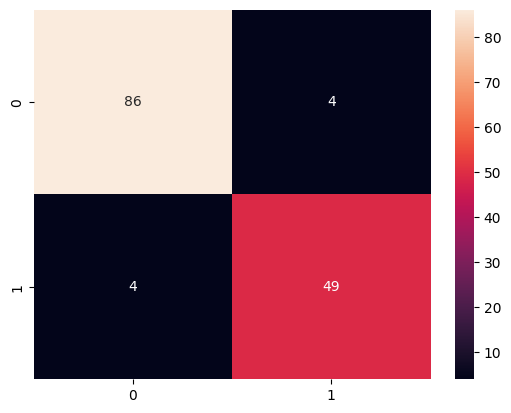

In [135]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True)

In [136]:
# Get accuracy score for model
from sklearn.metrics import accuracy_score
BaselineScore = accuracy_score(Y_test, Y_pred)
accuracy_score(Y_test, Y_pred)

0.9440559440559441

### Improvment

In [137]:
# Split into independent and dependent datasets
X = df.drop(columns=["diagnosis", "id", "fractal_dimension_worst"]).values
Y = df["diagnosis"].values

# !!! -> excluding "fractal_dimension_worst" column, include instead 

In [ ]:
# Split datasets into training(75%) and testing(25%)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0, stratify=Y) # we chose this change

# !!! -> not preserving class balance, use stratify=Y instead

In [139]:
# Scale data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [140]:
# Build a logistic regression classifier
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

classifier.fit(X_train, Y_train)
classifier.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [141]:
# Use trained model to make predictions on test data
Y_pred = classifier.predict(X_test)

<Axes: >

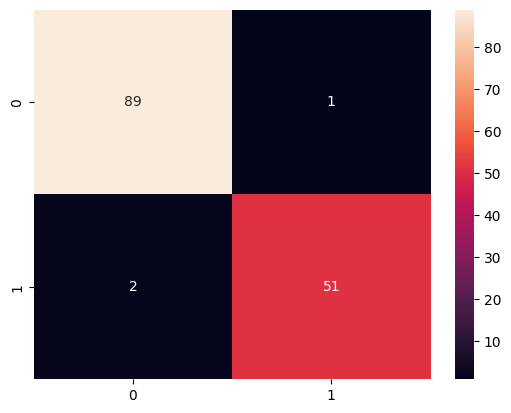

In [142]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True)

In [143]:
# Get accuracy score for model
from sklearn.metrics import accuracy_score
ImproveScore = accuracy_score(Y_test, Y_pred)
accuracy_score(Y_test, Y_pred)

0.9790209790209791

### Compare

In [144]:
print(f"Basline Score: {BaselineScore}")
print(f"Improve Score: {ImproveScore}")
print(f"Overall Improvment: {ImproveScore-BaselineScore}")

Basline Score: 0.9440559440559441
Improve Score: 0.9790209790209791
Overall Improvment: 0.034965034965035
